In [1]:
# ============================================================
# CELL 1: INSTALL AND IMPORT LIBRARIES
# ============================================================

#core libraries
import os
import cv2
import pickle
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#image processing libraries
from PIL import Image
from tqdm import tqdm

#similarity metrics
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

#deep learning libraries
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

#CLIP libraries
import torch
from transformers import CLIPProcessor, CLIPModel

print("All libraries installed and imported successfully.")
print("TensorFlow GPU Available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("Torch Device:", "cuda" if torch.cuda.is_available() else "cpu")

c:\MiniForge\envs\intern_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries installed and imported successfully.
TensorFlow GPU Available: False
Torch Device: cuda


In [2]:
# ============================================================
# CELL 2: LOAD DATASET AND VERIFY IMAGES
# ============================================================
# This cell:
# - loads styles.csv
# - creates image paths
# - checks missing/corrupted images
# - keeps only valid images

IMAGE_DIR = "dataset/images"
CSV_PATH = "dataset/styles.csv"

metadata = pd.read_csv(CSV_PATH, on_bad_lines="skip")

# Create image filename
metadata["image"] = metadata["id"].astype(str) + ".jpg"

# Create full image path
metadata["image_path"] = metadata["image"].apply(
    lambda image_name: os.path.join(IMAGE_DIR, image_name)
)

valid_rows = []

for _, row in tqdm(metadata.iterrows(),
                   total=len(metadata),
                   desc="Checking Dataset Images"):

    image_path = row["image_path"]

    # Check file exists
    if not os.path.exists(image_path):
        continue

    # Check image is readable
    image = cv2.imread(image_path)

    if image is None:
        continue

    valid_rows.append(row)

# Keep only valid rows
metadata = pd.DataFrame(valid_rows).reset_index(drop=True)

print("Dataset verification completed.")
print("Total valid images:", len(metadata))

metadata.head()

Checking Dataset Images: 100%|██████████| 44424/44424 [00:57<00:00, 772.31it/s] 


Dataset verification completed.
Total valid images: 44419


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg,dataset/images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg,dataset/images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg,dataset/images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,21379.jpg,dataset/images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,53759.jpg,dataset/images\53759.jpg


In [3]:
# ============================================================
# CELL 3: LOAD PRETRAINED CNN FEATURE EXTRACTOR
# ============================================================

# MobileNetV2 is used because:
# - lightweight
# - fast
# - efficient
# - excellent for similarity search

cnn_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")
print("Feature vector shape:", cnn_model.output_shape)

MobileNetV2 loaded successfully.
Feature vector shape: (None, 1280)


In [4]:
# ============================================================
# CELL 4: IMAGE PREPROCESSING
# ============================================================

def preprocess_image(image_path):
    """
    Loads, resizes, converts, and preprocesses an image for MobileNetV2.
    """

    image = cv2.imread(image_path)

    if image is None:
        return None

    # Convert BGR to RGB, resize, and preprocess for MobileNetV2
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image = np.array(image, dtype=np.float32)
    image = preprocess_input(image)
    image = np.expand_dims(image, axis=0)

    return image

In [5]:
# ============================================================
# CELL 5: CNN FEATURE EXTRACTION FUNCTION
# ============================================================

# Extracts normalized CNN feature vector from an image using the pretrained MobileNetV2 model
def extract_cnn_features(image_path):
    """
    Extracts normalized CNN feature vector from an image.
    """

    image = preprocess_image(image_path)

    if image is None:
        return None

    features = cnn_model.predict(image, verbose=0).flatten()
    features = features / np.linalg.norm(features)

    return features

In [6]:
# ============================================================
# CELL 6: BUILD AND SAVE CNN FEATURE DATABASE
# ============================================================

# Extract CNN features for all valid images and save them along with metadata and image paths
cnn_features = []
image_paths = []
valid_rows = []

# Use tqdm to show progress while extracting features
for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Extracting CNN features"):
    image_path = row["image_path"]

    features = extract_cnn_features(image_path)

    if features is not None:
        cnn_features.append(features)
        image_paths.append(image_path)
        valid_rows.append(row)

cnn_features = np.array(cnn_features, dtype=np.float32)
valid_metadata = pd.DataFrame(valid_rows).reset_index(drop=True)

with open('models/cnn_features.pkl', "wb") as f:
    pickle.dump(cnn_features, f)

with open('models/image_paths.pkl', "wb") as f:
    pickle.dump(image_paths, f)

with open('models/valid_metadata.pkl', "wb") as f:
    pickle.dump(valid_metadata, f)

print("CNN feature database saved successfully.")
print("Feature shape:", cnn_features.shape)
print("Valid images:", len(image_paths))

Extracting CNN features: 100%|██████████| 44419/44419 [1:27:56<00:00,  8.42it/s]


CNN feature database saved successfully.
Feature shape: (44419, 1280)
Valid images: 44419


In [8]:
# ============================================================
# CELL 7: LOAD SAVED CNN DATABASE
# ============================================================

with open('models/cnn_features.pkl', "rb") as f:
    cnn_features = pickle.load(f)

with open('models/image_paths.pkl', "rb") as f:
    image_paths = pickle.load(f)

with open('models/valid_metadata.pkl', "rb") as f:
    valid_metadata = pickle.load(f)

cnn_features = np.array(cnn_features, dtype=np.float32)

print("CNN database loaded successfully.")
print("Feature shape:", cnn_features.shape)
print("Total images:", len(image_paths))

CNN database loaded successfully.
Feature shape: (44419, 1280)
Total images: 44419


In [9]:
# ============================================================
# CELL 8: FILTER DATABASE BY CATEGORY FUNCTION
# ============================================================

def get_filtered_database(category="All"):
    """
    Returns filtered features, paths, and metadata based on selected category.
    """

    if category != "All":
        filtered_metadata = valid_metadata[valid_metadata["masterCategory"] == category]
        filtered_indices = filtered_metadata.index.tolist()

        filtered_features = cnn_features[filtered_indices]
        filtered_paths = [image_paths[i] for i in filtered_indices]
        filtered_metadata = valid_metadata.iloc[filtered_indices].reset_index(drop=True)

        return filtered_features, filtered_paths, filtered_metadata

    return cnn_features, image_paths, valid_metadata.reset_index(drop=True)


In [10]:
# ============================================================
# CELL 9: COSINE SIMILARITY SEARCH FUNCTION
# ============================================================

# This function takes a query image path, extracts its CNN features, filters the database by category, 
# computes cosine similarity with all database features, and returns the top K most similar images along with their metadata and similarity scores.
def search_by_cosine(query_image_path, top_k=5, category="All"):
    """
    Searches similar images using cosine similarity.
    """

    query_features = extract_cnn_features(query_image_path)

    if query_features is None:
        raise ValueError("Query image could not be processed.")

    filtered_features, filtered_paths, filtered_metadata = get_filtered_database(category)

    similarities = cosine_similarity([query_features], filtered_features)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []

    for idx in top_indices:
        results.append({
            "image_path": filtered_paths[idx],
            "score": float(similarities[idx]),
            "product_name": filtered_metadata.iloc[idx].get("productDisplayName", "Unknown"),
            "category": filtered_metadata.iloc[idx].get("masterCategory", "Unknown"),
            "sub_category": filtered_metadata.iloc[idx].get("subCategory", "Unknown"),
            "article_type": filtered_metadata.iloc[idx].get("articleType", "Unknown")
        })

    return results


In [11]:
# ============================================================
# CELL 10: EUCLIDEAN DISTANCE SEARCH FUNCTION
# ============================================================

# This function takes a query image path, extracts its CNN features, filters the database by category,
# computes Euclidean distance with all database features, and returns the top K most similar images along with their metadata and distance scores. 
# Lower score means more similar.

def search_by_euclidean(query_image_path, top_k=5, category="All"):
    """
    Searches similar images using Euclidean distance.
    Lower score means more similar.
    """

    query_features = extract_cnn_features(query_image_path)

    if query_features is None:
        raise ValueError("Query image could not be processed.")

    filtered_features, filtered_paths, filtered_metadata = get_filtered_database(category)

    distances = euclidean_distances([query_features], filtered_features)[0]
    top_indices = np.argsort(distances)[:top_k]

    results = []

    for idx in top_indices:
        results.append({
            "image_path": filtered_paths[idx],
            "score": float(distances[idx]),
            "product_name": filtered_metadata.iloc[idx].get("productDisplayName", "Unknown"),
            "category": filtered_metadata.iloc[idx].get("masterCategory", "Unknown"),
            "sub_category": filtered_metadata.iloc[idx].get("subCategory", "Unknown"),
            "article_type": filtered_metadata.iloc[idx].get("articleType", "Unknown")
        })

    return results

In [12]:
# ============================================================
# CELL 11: BUILD AND SAVE FAISS INDEX
# ============================================================

dimension = cnn_features.shape[1]

faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(cnn_features)

faiss.write_index(faiss_index, "models/faiss_index.bin")

print("FAISS index created and saved successfully.")
print("Total indexed images:", faiss_index.ntotal)

FAISS index created and saved successfully.
Total indexed images: 44419


In [13]:
# ============================================================
# CELL 12: FAISS FAST SIMILARITY SEARCH
# ============================================================

faiss_index = faiss.read_index("models/faiss_index.bin")
def search_by_faiss(query_image_path, top_k=5):
    """
    Searches similar images using FAISS.
    FAISS is faster and better for large datasets.
    """

    query_features = extract_cnn_features(query_image_path)

    if query_features is None:
        raise ValueError("Query image could not be processed.")

    query_features = np.array([query_features], dtype=np.float32)

    scores, indices = faiss_index.search(query_features, top_k)

    results = []

    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "image_path": image_paths[idx],
            "score": float(score),
            "product_name": valid_metadata.iloc[idx].get("productDisplayName", "Unknown"),
            "category": valid_metadata.iloc[idx].get("masterCategory", "Unknown"),
            "sub_category": valid_metadata.iloc[idx].get("subCategory", "Unknown"),
            "article_type": valid_metadata.iloc[idx].get("articleType", "Unknown")
        })

    return results

In [14]:
# ============================================================
# CELL 13: CATEGORY FILTERING AND RESULT DISPLAY
# ============================================================

categories = ["All"] + sorted(valid_metadata["masterCategory"].dropna().unique().tolist())

print("Available categories:")
print(categories)


def display_results(query_image_path, results, title="Search Results"):
    """
    Displays query image and similar images.
    """

    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(query_image_path))
    plt.title("Query Image")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(18, 5))

    for i, result in enumerate(results):
        image = Image.open(result["image_path"])
        name = result["product_name"]

        if len(name) > 25:
            name = name[:25] + "..."

        plt.subplot(1, len(results), i + 1)
        plt.imshow(image)
        plt.title(f"{name}\nScore: {result['score']:.4f}", fontsize=9)
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.show()

Available categories:
['All', 'Accessories', 'Apparel', 'Footwear', 'Free Items', 'Home', 'Personal Care', 'Sporting Goods']


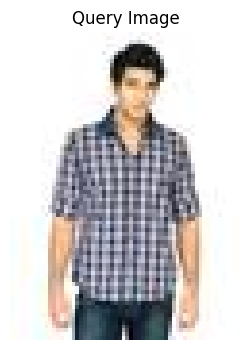

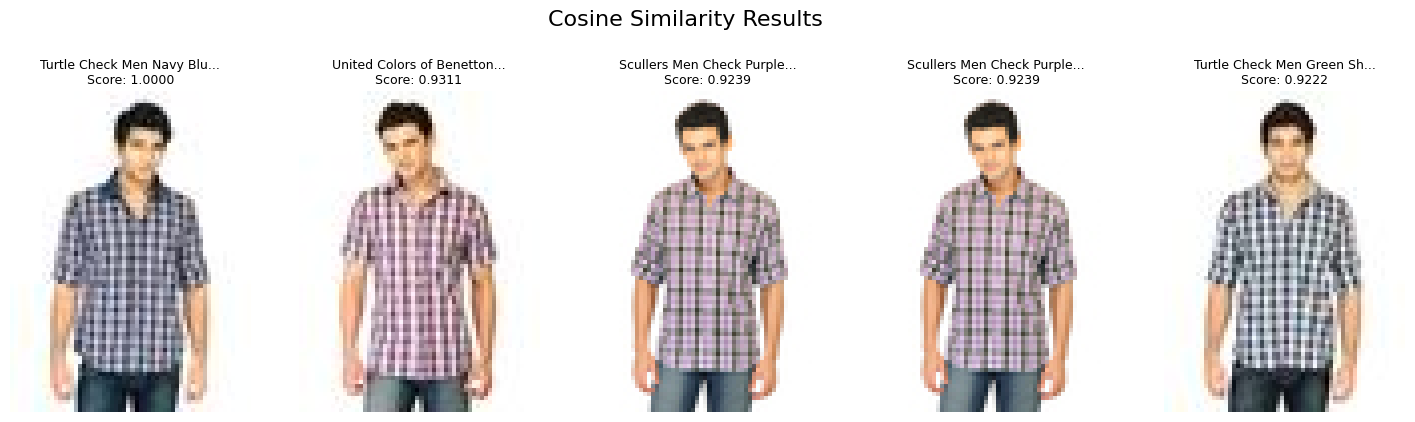

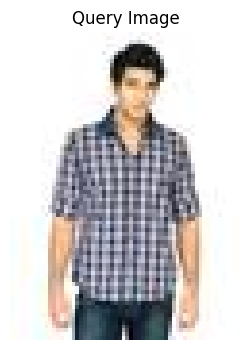

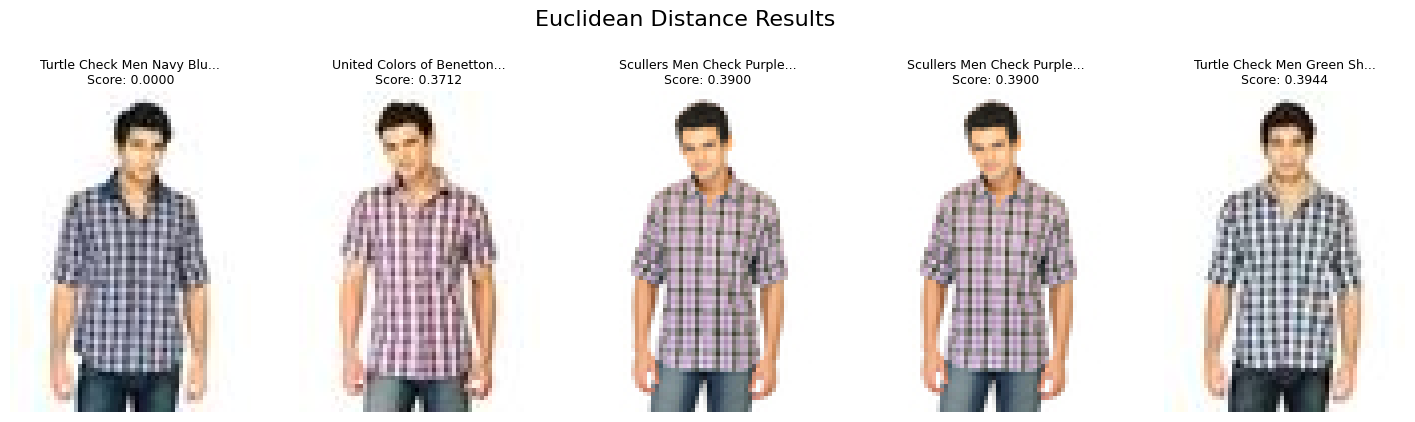

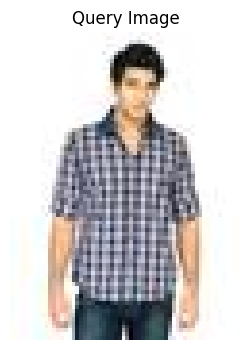

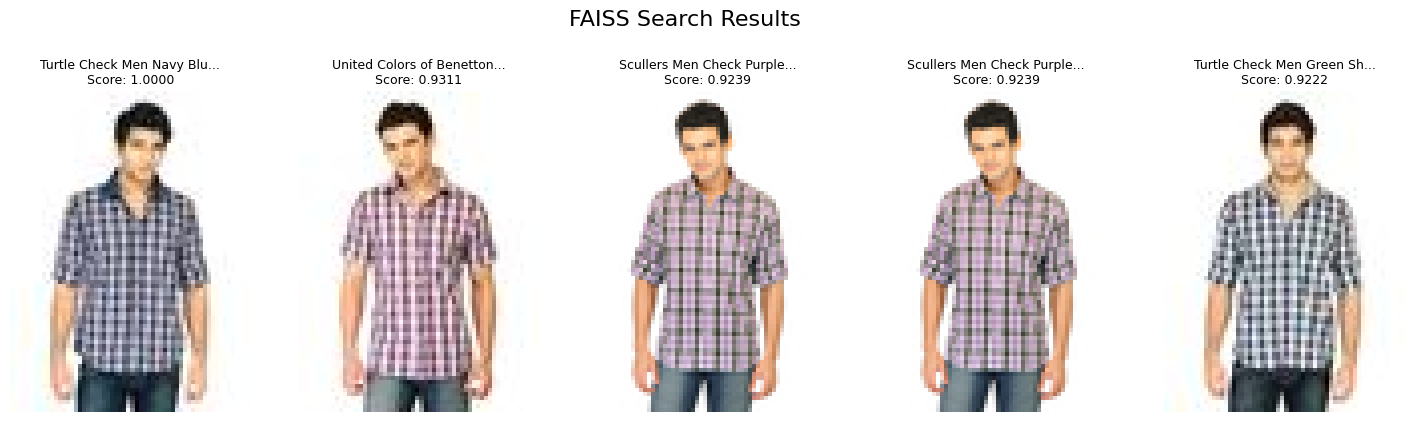

In [15]:
# ============================================================
# CELL 14: TEST CNN/FAISS SIMILARITY SEARCH
# ============================================================

query_image_path = image_paths[0]

cosine_results = search_by_cosine(query_image_path, top_k=5, category="All")
display_results(query_image_path, cosine_results, "Cosine Similarity Results")

euclidean_results = search_by_euclidean(query_image_path, top_k=5, category="All")
display_results(query_image_path, euclidean_results, "Euclidean Distance Results")

faiss_results = search_by_faiss(query_image_path, top_k=5)
display_results(query_image_path, faiss_results, "FAISS Search Results")

In [16]:
# ============================================================
# CELL 15: LOAD PRETRAINED CLIP MODEL
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP loaded successfully.")
print("Device:", device)

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 1aa49b7e-d74a-4615-8028-5a3a121cc140)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 0b07c21d-6592-477c-8d92-da43f9976209)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 88478b6a-ae81-43f7-a56b-939748044300)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d

CLIP loaded successfully.
Device: cuda


In [17]:
# ============================================================
# CELL 16: BUILD AND SAVE CLIP DATABASE
# ============================================================

def extract_clip_image_features(image_path):
    """
    Extracts semantic image features using CLIP.
    """

    try:
        image = Image.open(image_path).convert("RGB")

        inputs = clip_processor(
            images=image,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            features = clip_model.get_image_features(**inputs)

        features = features.cpu().numpy().flatten()
        features = features / np.linalg.norm(features)

        return features

    except Exception:
        return None


clip_features_list = []
clip_image_paths = []
clip_rows = []

for _, row in tqdm(valid_metadata.iterrows(), total=len(valid_metadata), desc="Extracting CLIP features"):
    image_path = row["image_path"]
    features = extract_clip_image_features(image_path)

    if features is not None:
        clip_features_list.append(features)
        clip_image_paths.append(image_path)
        clip_rows.append(row)

clip_features_array = np.array(clip_features_list, dtype=np.float32)
clip_metadata = pd.DataFrame(clip_rows).reset_index(drop=True)

with open('models/clip_features_array.pkl', "wb") as f:
    pickle.dump(clip_features_array, f)

with open('models/clip_image_paths.pkl', "wb") as f:
    pickle.dump(clip_image_paths, f)

with open('models/clip_metadata.pkl', "wb") as f:
    pickle.dump(clip_metadata, f)

clip_index = faiss.IndexFlatIP(clip_features_array.shape[1])
clip_index.add(clip_features_array)

faiss.write_index(clip_index, 'models/clip_faiss_index.bin')

print("CLIP database and FAISS index saved.")
print("CLIP feature shape:", clip_features_array.shape)

Extracting CLIP features: 100%|██████████| 44419/44419 [27:58<00:00, 26.46it/s] 


CLIP database and FAISS index saved.
CLIP feature shape: (44419, 512)


In [18]:
# ============================================================
# CELL 17: CLIP IMAGE AND TEXT SEARCH
# ============================================================

# Load CLIP FAISS index for fast similarity search
clip_index = faiss.read_index('models/clip_faiss_index.bin')

# This function takes a text query, extracts CLIP text features, computes cosine similarity with all CLIP image features in the database, 
# and returns the top K most similar images along with their metadata and similarity scores.

def extract_clip_text_features(text_query):
    """
    Extracts normalized CLIP text features.
    """
    inputs = clip_processor(
        text=[text_query],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)

    features = features.cpu().numpy().flatten()
    features = features / np.linalg.norm(features)

    return features




In [19]:
# ============================================================
# CELL 18: CLIP IMAGE SEARCH FUNCTION
# ============================================================

# This function takes a query image path, extracts its CLIP image features, computes cosine similarity with all CLIP image features in the database,
# and returns the top K most similar images along with their metadata and similarity scores.
def search_clip_image(query_image_path, top_k=5):
    """
    Searches images using CLIP image embeddings.
    """
    query_features = extract_clip_image_features(query_image_path)
    query_features = np.array([query_features], dtype=np.float32)

    scores, indices = clip_index.search(query_features, top_k)

    results = []

    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "image_path": clip_image_paths[idx],
            "score": float(score),
            "product_name": clip_metadata.iloc[idx].get("productDisplayName", "Unknown"),
            "category": clip_metadata.iloc[idx].get("masterCategory", "Unknown"),
            "sub_category": clip_metadata.iloc[idx].get("subCategory", "Unknown"),
            "article_type": clip_metadata.iloc[idx].get("articleType", "Unknown")
        })

    return results




In [20]:
# ============================================================
# CELL 19: CLIP TEXT SEARCH FUNCTION
# ============================================================

# This function takes a text query, extracts CLIP text features, computes cosine similarity with all CLIP image features in the database,
# and returns the top K most similar images along with their metadata and similarity scores.
def search_clip_text(text_query, top_k=5):
    """
    Searches images using text query.
    Example: black sports shoes
    """
    query_features = extract_clip_text_features(text_query)
    query_features = np.array([query_features], dtype=np.float32)

    scores, indices = clip_index.search(query_features, top_k)

    results = []

    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "image_path": clip_image_paths[idx],
            "score": float(score),
            "product_name": clip_metadata.iloc[idx].get("productDisplayName", "Unknown"),
            "category": clip_metadata.iloc[idx].get("masterCategory", "Unknown"),
            "sub_category": clip_metadata.iloc[idx].get("subCategory", "Unknown"),
            "article_type": clip_metadata.iloc[idx].get("articleType", "Unknown")
        })

    return results

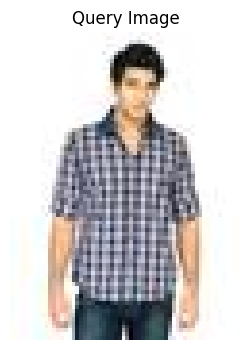

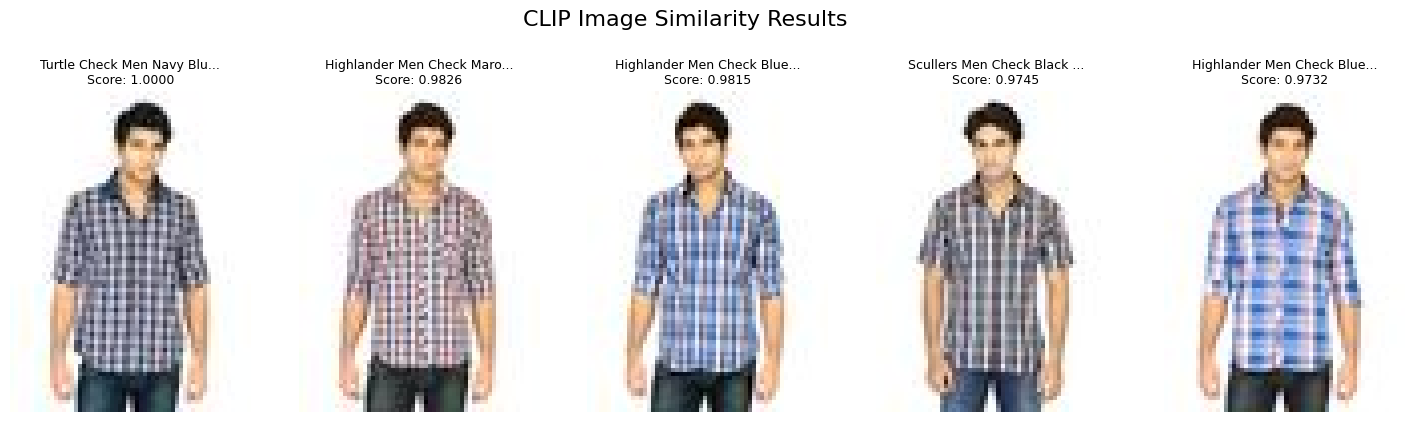

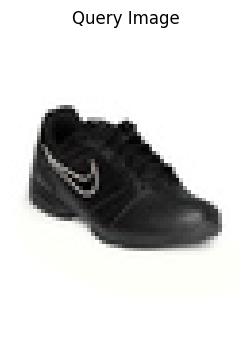

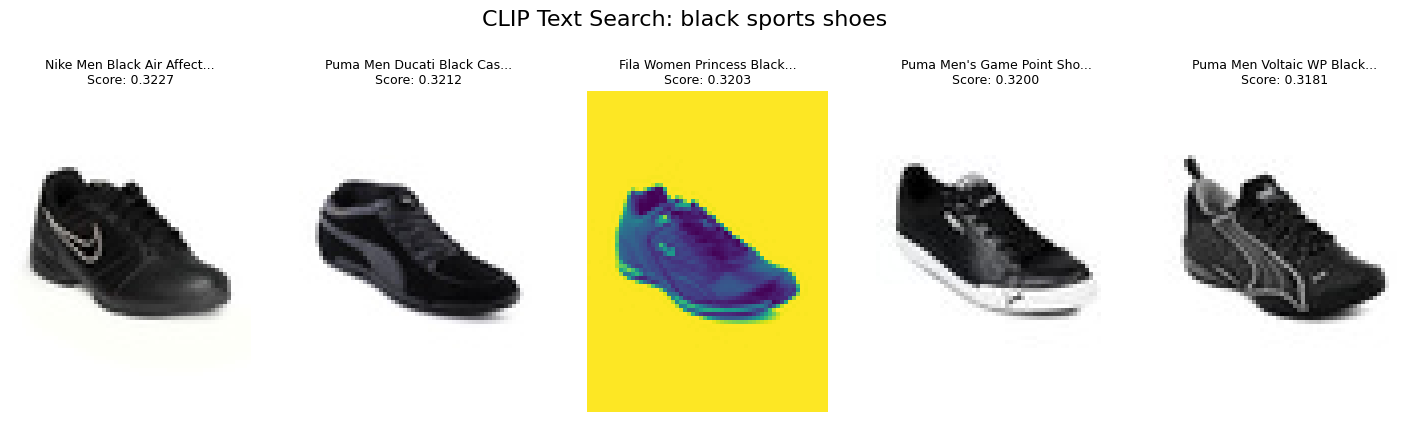

In [21]:
# ============================================================
# CELL 20: TEST CLIP SEARCH
# ============================================================

# Test CLIP image similarity search and text search
clip_image_results = search_clip_image(
    query_image_path=query_image_path,
    top_k=5
)

# display CLIP image search results
display_results(query_image_path, clip_image_results, "CLIP Image Similarity Results")

text_query = "black sports shoes"

clip_text_results = search_clip_text(
    text_query=text_query,
    top_k=5
)

display_results(
    clip_text_results[0]["image_path"],
    clip_text_results,
    f"CLIP Text Search: {text_query}"
)